# Practical 5: Image Deblurring using Inverse and Wiener Filter

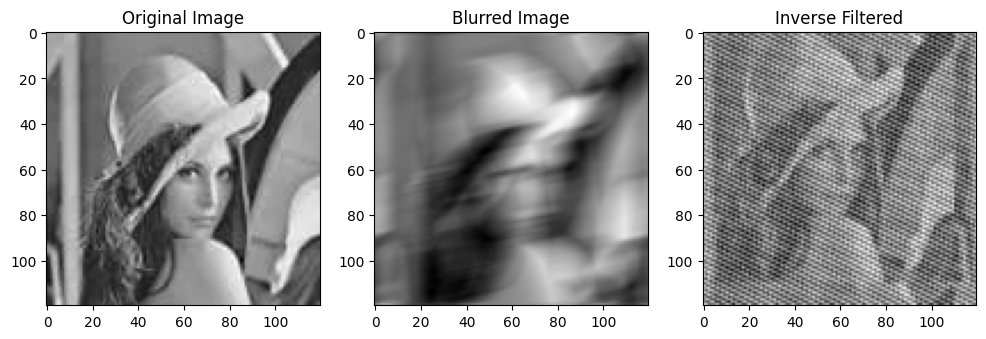

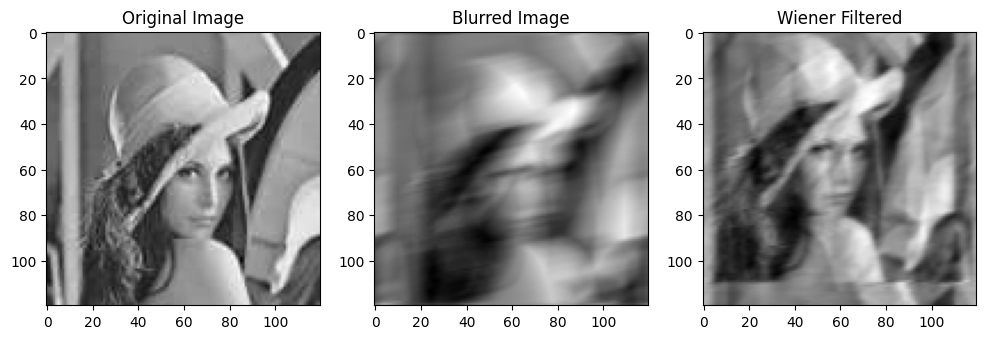

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

def motion_blur(image, kernel_size, angle):
    """Applies motion blur to an image."""
    kernel = np.zeros((kernel_size, kernel_size))
    kernel[int((kernel_size - 1) / 2), :] = np.ones(kernel_size)
    kernel = cv2.warpAffine(kernel, cv2.getRotationMatrix2D((kernel_size / 2 - 0.5, kernel_size / 2 - 0.5), angle, 1.0), (kernel_size, kernel_size))
    kernel = kernel / np.sum(kernel)
    blurred = convolve2d(image, kernel, mode='same', boundary='wrap')
    return blurred

def inverse_filter(blurred, kernel, eps):
    """Applies inverse filtering to deblur an image."""
    blurred_fft = np.fft.fft2(blurred)
    kernel_fft = np.fft.fft2(kernel, s=blurred.shape)
    deblurred_fft = blurred_fft / (kernel_fft + eps) # Add eps to avoid division by zero
    deblurred = np.fft.ifft2(deblurred_fft).real
    return deblurred

def wiener_filter(blurred, kernel, k):
    """Applies Wiener filtering to deblur an image."""
    blurred_fft = np.fft.fft2(blurred)
    kernel_fft = np.fft.fft2(kernel, s=blurred.shape)
    kernel_fft_conj = np.conj(kernel_fft)
    deblurred_fft = (kernel_fft_conj / (np.abs(kernel_fft) ** 2 + k)) * blurred_fft
    deblurred = np.fft.ifft2(deblurred_fft).real
    return deblurred

# Load image and apply motion blur
IMG_PATH = "C:/Users/shiva/Downloads/lina.jpeg"
img = cv2.imread(IMG_PATH, cv2.IMREAD_GRAYSCALE)
kernel_size = 21
angle = 11
blurred = motion_blur(img, kernel_size, angle)

# Create blur kernel
kernel = np.zeros((kernel_size, kernel_size))
kernel[int((kernel_size - 1) / 2), :] = np.ones(kernel_size)
kernel = cv2.warpAffine(kernel, cv2.getRotationMatrix2D((kernel_size / 2 - 0.5, kernel_size / 2 - 0.5), angle, 1.0), (kernel_size, kernel_size))
kernel = kernel / np.sum(kernel)

# Deblur using inverse filtering
deblurred_inverse = inverse_filter(blurred, kernel, 0.01)

# Deblur using Wiener filtering
deblurred_wiener = wiener_filter(blurred, kernel, 0.01)

# Display results
plt.figure(figsize=(12, 6))
plt.subplot(131), plt.imshow(img, cmap='gray'), plt.title('Original Image')
plt.subplot(132), plt.imshow(blurred, cmap='gray'), plt.title('Blurred Image')
plt.subplot(133), plt.imshow(deblurred_inverse, cmap='gray'), plt.title('Inverse Filtered')
plt.show()

plt.figure(figsize=(12, 6))
plt.subplot(131), plt.imshow(img, cmap='gray'), plt.title('Original Image')
plt.subplot(132), plt.imshow(blurred, cmap='gray'), plt.title('Blurred Image')
plt.subplot(133), plt.imshow(deblurred_wiener, cmap='gray'), plt.title('Wiener Filtered')
plt.show()